# Imports

In [113]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [114]:
#base
import pandas as pd
import numpy as np
# visual
import matplotlib.pyplot as plt
import seaborn as sns
#path
from pathlib import Path
#system
import sys
sys.path.append(str(SRC_DIR))
#pipeline
from preproc import HousePreprocessor, optimize_dtypes
from features import FeatureEngineer, add_log_target
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
# models
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from catboost import CatBoostRegressor
import lightgbm as lgb
from xgboost import XGBRegressor
# metrics
from sklearn.metrics import root_mean_squared_error
#mlflow
import mlflow
import mlflow.sklearn
mlflow.set_tracking_uri("file:///C:/mlflow_runs")
mlflow.set_experiment("house-prices")

<Experiment: artifact_location='file:///C:/mlflow_runs/229563118780063873', creation_time=1781280435250, experiment_id='229563118780063873', last_update_time=1781280435250, lifecycle_stage='active', name='house-prices', tags={}, trace_location=None, workspace='default'>

## Settings

In [115]:
# Path
BASE_DIR = Path.cwd().parent
DATA_DIR   = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SRC_DIR = BASE_DIR / "src"

TRAIN_PATH = DATA_DIR / "raw" / "train.csv"

RANDOM_SEED = 42

In [116]:
# visual
%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 12
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False 
plt.rcParams["axes.spines.right"] = False

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.2)
sns.set_context("notebook")

COLORS = {
    'positive': '#2ecc71',
    'negative': '#e74c3c',
    'neutral': '#3498db',
    'highlight': '#f39c12',
    'secondary': '#9b59b6',
}

# Data Load

In [117]:
assert TRAIN_PATH.exists(), f'File not founded: {TRAIN_PATH}'
df = pd.read_csv(TRAIN_PATH)

In [118]:
print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Models

## Baseline (Linear Regression)

In [119]:
lasso = Lasso(random_state=RANDOM_SEED, alpha=0.001)
ridge = Ridge(random_state=RANDOM_SEED, alpha=1.0)
elasticnet = ElasticNet(random_state=RANDOM_SEED,  alpha=0.001, l1_ratio=0.5)

## Base Pipeline

In [120]:
df_prepared = add_log_target(df)

In [121]:
X_train = df_prepared.drop(columns=['Id', 'SalePrice'])
y_train = df_prepared['SalePrice'] 

In [122]:
models = [
    lasso,
    ridge,
    elasticnet,
]

2026/06/12 21:26:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 21:26:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Lasso RMSE: 0.2856


2026/06/12 21:26:59 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\2BA0~1\AppData\Local\Temp\tmprkjzg6j4\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


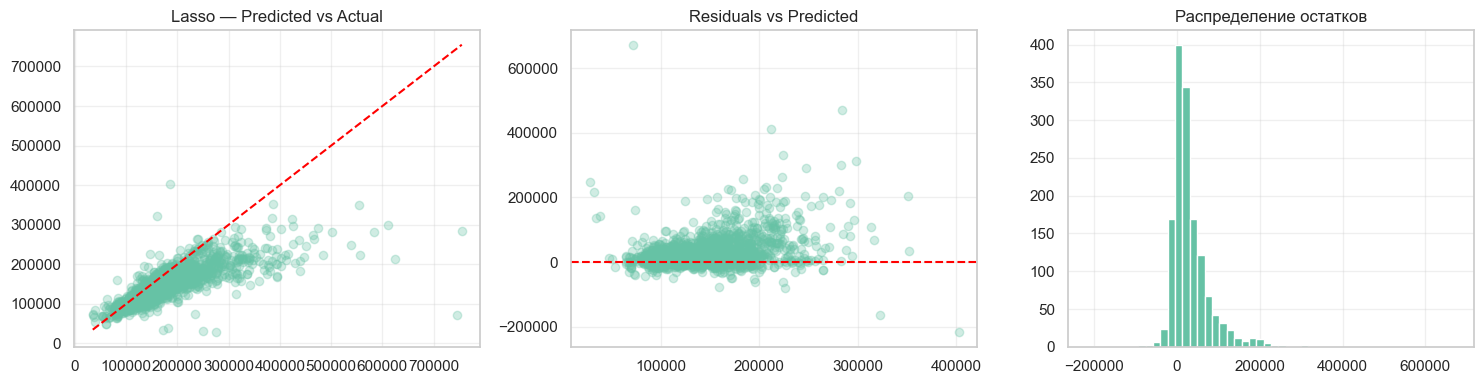

2026/06/12 21:27:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 21:27:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge RMSE: 0.3025


2026/06/12 21:27:04 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\2BA0~1\AppData\Local\Temp\tmpwsx_rkk2\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


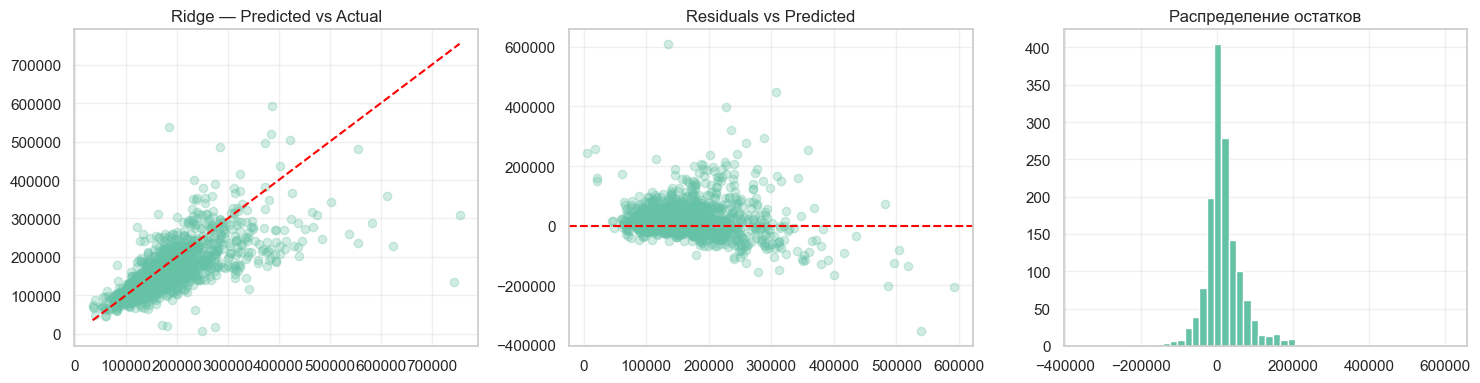

2026/06/12 21:27:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 21:27:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


ElasticNet RMSE: 0.2817


2026/06/12 21:27:09 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\2BA0~1\AppData\Local\Temp\tmp5vqiup83\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


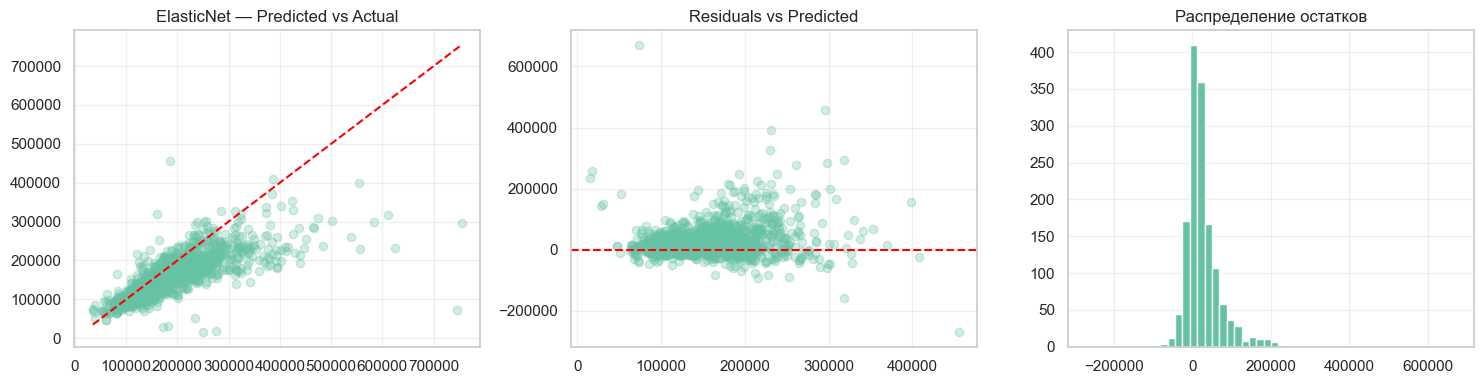

In [123]:
for model in models:
    with mlflow.start_run(run_name=model.__class__.__name__):

        # Tags
        ## Main Tag
        mlflow.set_tag("notes", "baseline с изменением альфа")
        ## Others
        mlflow.set_tag("feature_engineering", "v2 = Quality Features")
        mlflow.set_tag("preprocessing", "clip + fillna")

        
        pipe = Pipeline([
            ("preprocessor", HousePreprocessor()),
            ("feature_engineer", FeatureEngineer()),
            ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
            ("imputer", SimpleImputer(strategy="median").set_output(transform="pandas")),
            ("scaler", StandardScaler()),
            ("model", model),
        ])
    
        y_pred_log = cross_val_predict(pipe, X_train, y_train, cv=kf)
        
        y_pred = np.expm1(y_pred_log)
        y_true = np.expm1(y_train)
        residuals = y_true - y_pred
        
        rmse = root_mean_squared_error(y_train, y_pred_log)
        print(f"{model.__class__.__name__} RMSE: {rmse:.4f}")

        # логирование модели
        mlflow.log_params(model.get_params())
        # логирование метрики
        mlflow.log_metric("rmsle_cv", rmse)

        # логирование pipeline целиком
        pipe.fit(X_train, y_train)
        mlflow.sklearn.log_model(pipe, "pipeline")
    
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
        axes[0].scatter(y_true, y_pred, alpha=0.3)
        axes[0].plot([y_true.min(), y_true.max()],
                     [y_true.min(), y_true.max()], 'r--')
        axes[0].set_title(f'{model.__class__.__name__} — Predicted vs Actual')
    
        axes[1].scatter(y_pred, residuals, alpha=0.3)
        axes[1].axhline(0, color='r', linestyle='--')
        axes[1].set_title('Residuals vs Predicted')
    
        axes[2].hist(residuals, bins=50)
        axes[2].set_title('Распределение остатков')
    
        plt.tight_layout()
        mlflow.log_figure(fig, f"{model.__class__.__name__}_residuals.png")
        plt.show()

## CatBoost, LightGBM, XGboost

In [124]:
catboost = CatBoostRegressor(verbose=0)
lightgbm = lgb.LGBMRegressor(verbose=-1)
xgboost = XGBRegressor(verbosity=0)
models = [
    catboost,
    lightgbm,
    xgboost,
]

In [125]:
df_prepared = add_log_target(df)
X_train = df_prepared.drop(columns=['Id', 'SalePrice'])
y_train = df_prepared['SalePrice']

CatBoostRegressor RMSE: 0.3756


2026/06/12 21:27:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 21:27:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/12 21:27:44 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\2BA0~1\AppData\Local\Temp\tmpz00_8ylg\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


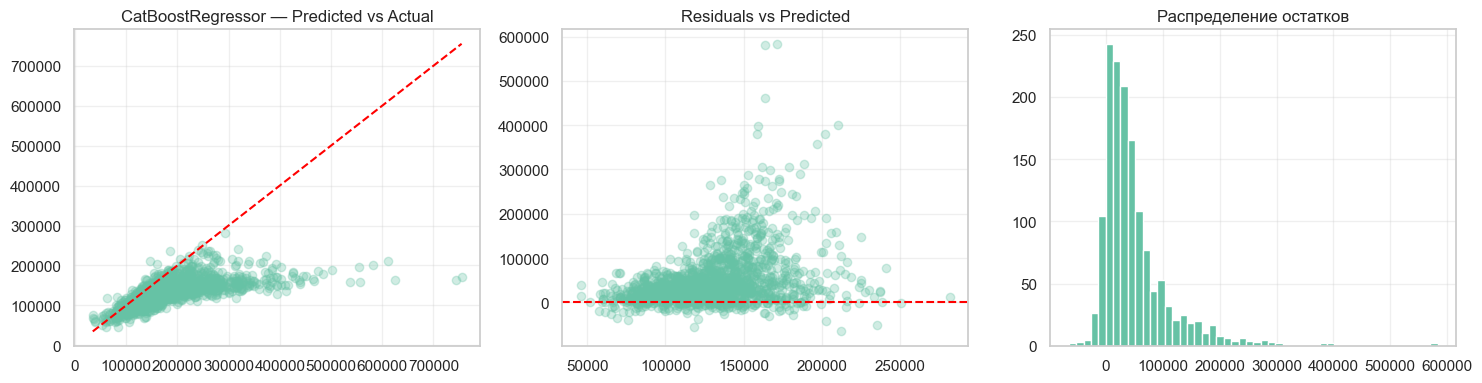

C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LGBMRegressor RMSE: 0.4455


2026/06/12 21:27:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 21:27:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/12 21:27:51 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\2BA0~1\AppData\Local\Temp\tmppu6djko1\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


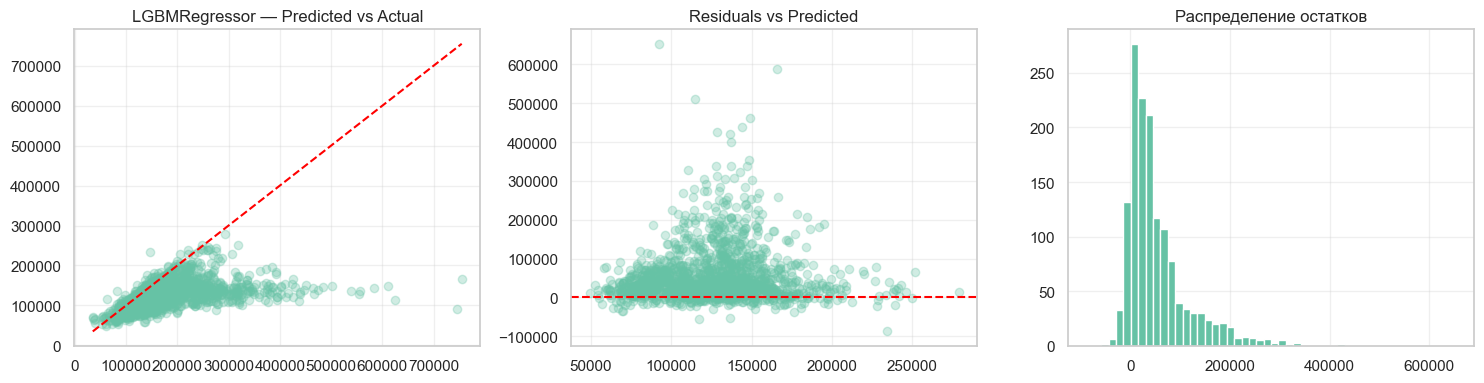

XGBRegressor RMSE: 0.4063


2026/06/12 21:27:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 21:27:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/12 21:27:57 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\2BA0~1\AppData\Local\Temp\tmp175ekdwg\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


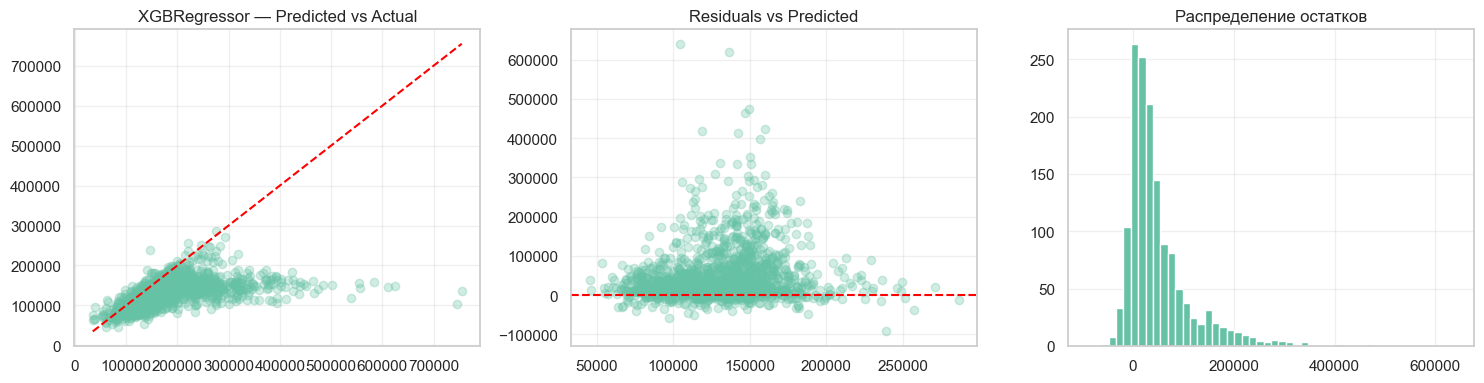

In [126]:
for model in models:
    with mlflow.start_run(run_name=model.__class__.__name__):

        # Tags
        ## Main Tag
        mlflow.set_tag("notes", "Boosting Models")
        ## Others
        mlflow.set_tag("feature_engineering", "v2 = Quality Features")
        mlflow.set_tag("preprocessing", "clip + fillna")

        
        pipe = Pipeline([
            ("preprocessor", HousePreprocessor()),
            ("feature_engineer", FeatureEngineer()),
            ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
            ("imputer", SimpleImputer(strategy="median").set_output(transform="pandas")),
            ("scaler", StandardScaler()),
            ("model", model),
        ])
    
        y_pred_log = cross_val_predict(pipe, X_train, y_train, cv=kf)
        
        y_pred = np.expm1(y_pred_log)
        y_true = np.expm1(y_train)
        residuals = y_true - y_pred
        
        rmse = root_mean_squared_error(y_train, y_pred_log)
        print(f"{model.__class__.__name__} RMSE: {rmse:.4f}")

        # логирование модели
        mlflow.log_params(model.get_params())
        # логирование метрики
        mlflow.log_metric("rmsle_cv", rmse)

        # логирование pipeline целиком
        pipe.fit(X_train, y_train)
        mlflow.sklearn.log_model(pipe, "pipeline")
    
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
        axes[0].scatter(y_true, y_pred, alpha=0.3)
        axes[0].plot([y_true.min(), y_true.max()],
                     [y_true.min(), y_true.max()], 'r--')
        axes[0].set_title(f'{model.__class__.__name__} — Predicted vs Actual')
    
        axes[1].scatter(y_pred, residuals, alpha=0.3)
        axes[1].axhline(0, color='r', linestyle='--')
        axes[1].set_title('Residuals vs Predicted')
    
        axes[2].hist(residuals, bins=50)
        axes[2].set_title('Распределение остатков')
    
        plt.tight_layout()
        mlflow.log_figure(fig, f"{model.__class__.__name__}_residuals.png")
        plt.show()

In [132]:
cb_features = pd.DataFrame(catboost.get_feature_importance(), columns=X_train.columns)
cb_features

ValueError: Shape of passed values is (106, 1), indices imply (106, 79)

In [134]:
catboost.get_feature_importance(prettified=True)

,Feature Id,Importances
0,85,22.603827
1,82,9.319670
2,95,5.940188
3,79,4.780940
4,37,3.624584
...,...,...
101,87,0.000277
102,8,0.000055
103,4,0.000000
104,90,0.000000
